In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv("../data/processed/ml_features_v1.csv")

In [3]:
import os
import sys
sys.path.append(os.path.abspath(".."))
from src.preprocessing import understand_data
understand_data(df)


DataFrame Shape: (2743335, 23)


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2743335 entries, 0 to 2743334
Data columns (total 23 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   Date                    object 
 1   Hour                    int64  
 2   Route                   int64  
 3   Stop                    int64  
 4   DayOfWeek               int64  
 5   Month                   int64  
 6   Year                    int64  
 7   is_weekend              int64  
 8   lag_1_row               float64
 9   Boardings_daily         float64
 10  Boardings_lag_1         int64  
 11  Boardings_lag_3         int64  
 12  Boardings_lag_7         int64  
 13  Boardings_lag_14        int64  
 14  Boardings_lag_30        int64  
 15  Boardings_roll_mean_3   float64
 16  Boardings_roll_mean_7   float64
 17  Boardings_roll_mean_30  float64
 18  Boardings_roll_std_30   float64
 19  hour_sin                float64
 20  hour_cos          

In [4]:
from src.model_building import prepare_data_for_modeling
X_train, y_train, X_test, y_test = prepare_data_for_modeling(df)

In [5]:
X_train.head()

,Hour,Route,Stop,DayOfWeek,Month,Year,is_weekend,lag_1_row,Boardings_daily,Boardings_lag_1,...,Boardings_lag_7,Boardings_lag_14,Boardings_lag_30,Boardings_roll_mean_3,Boardings_roll_mean_7,Boardings_roll_mean_30,Boardings_roll_std_30,hour_sin,hour_cos,Direction_SB
0,17,1,14,0,7,2017,0,5.0,15374.0,23297,...,7913,14107,13086,16962.333333,14201.142857,15168.266667,4559.942966,-0.965926,-2.588190e-01,True
352,7,1,7,0,7,2017,0,10.0,15374.0,23297,...,7913,14107,13086,16962.333333,14201.142857,15168.266667,4559.942966,0.965926,-2.588190e-01,True
351,6,1,23,0,7,2017,0,9.0,15374.0,23297,...,7913,14107,13086,16962.333333,14201.142857,15168.266667,4559.942966,1.000000,6.123234e-17,True
350,14,1,23,0,7,2017,0,23.0,15374.0,23297,...,7913,14107,13086,16962.333333,14201.142857,15168.266667,4559.942966,-0.500000,-8.660254e-01,True
349,5,5,20,0,7,2017,0,70.0,15374.0,23297,...,7913,14107,13086,16962.333333,14201.142857,15168.266667,4559.942966,0.965926,2.588190e-01,False


In [6]:
from src.model_building import baseline_model
y_pred_baseline =baseline_model(X_test)

In [7]:
from src.model_building import evaluate_model
evaluate_model(y_test,y_pred_baseline)


MAE: 16.26
MSE: 1143.19
RMSE: 33.81
R² Score: 0.2188


In [8]:
from src.model_building import gradient_boosting_model
y_pred_gb = gradient_boosting_model(X_train, y_train,X_test,200,0.4,5)

In [9]:
evaluate_model(y_test,y_pred_gb)

MAE: 9.33
MSE: 444.52
RMSE: 21.08
R² Score: 0.6962


In [10]:
from src.model_building import xgboost_model
model_xgb, y_pred_xgb = xgboost_model(X_train,y_train,X_test,500,0.3,5)

In [11]:
evaluate_model(y_test,y_pred_xgb)

MAE: 9.02
MSE: 415.92
RMSE: 20.39
R² Score: 0.7158


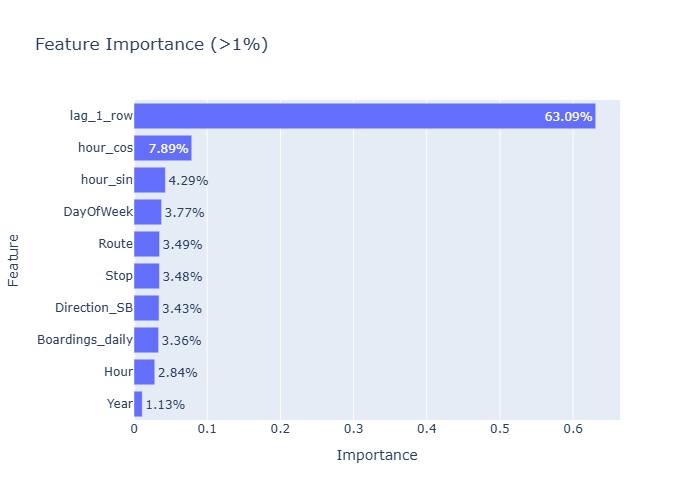

In [12]:
from src.model_building import feature_importance
feature_importance(model_xgb,X_train)